In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import netCDF4 as nc

import sys
sys.path.append('/home/z5297792/UNSW-MRes/MRes/SEACOFS_dataset') 
from clim_functions import tilt_distance_Li, plot_tilt_method, bearing


In [2]:
df_ameda = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/AMEDA/df_ameda_renamed.pkl')
df_tilt = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/AMEDA/df_tilt_ameda.pkl')
df_ameda = df_ameda.merge(
    df_tilt[['Eddy', 'Day', 'TiltDis', 'TiltDir']],
    how='left',
    left_on=['Eddy', 'Day'],
    right_on=['Eddy', 'Day']
)
df_AE = df_ameda[df_ameda.Cyc=='AE'].copy()
df_CE = df_ameda[df_ameda.Cyc=='CE'].copy()
df_ameda


,Eddy,Day,Cyc,lon,lat,ic,jc,xc,yc,w,...,split2,merge,merge2,shapes2,interaction,interaction2,area,deta,TiltDis,TiltDir
0,1,1462,AE,159.538447,-33.372496,256,186,895.838095,919.548973,0.00001,...,NaN,NaN,NaN,NaN,NaN,NaN,46653.514371,-0.000011,NaN,NaN
1,1,1463,AE,159.686966,-33.160751,257,192,903.002279,946.853133,0.000019,...,NaN,NaN,NaN,NaN,NaN,NaN,4313.383226,-0.000164,NaN,NaN
2,1,1464,AE,159.649836,-33.118402,256,192,898.424872,950.150915,0.000019,...,NaN,NaN,NaN,NaN,NaN,NaN,4336.799061,-0.00007,NaN,NaN
3,1,1465,AE,159.686966,-33.118402,257,193,901.765461,951.353349,0.000019,...,NaN,NaN,NaN,NaN,NaN,NaN,6480.379311,-0.000047,16.147158,80.585819
4,1,1466,AE,159.575577,-32.949006,254,196,886.770848,965.738198,0.00002,...,NaN,NaN,NaN,NaN,NaN,NaN,6101.676103,-0.000401,19.455358,63.680275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104565,3519,10643,CE,154.897235,-28.841152,125,252,327.112431,1244.142958,-0.000014,...,NaN,NaN,NaN,NaN,NaN,NaN,1147.953129,0.000186,5.535800,317.157035
104566,3519,10647,CE,154.860106,-29.052897,127,247,331.141370,1220.843200,-0.000011,...,NaN,NaN,NaN,NaN,NaN,NaN,8038.013328,0.000109,13.057427,343.183493
104567,3519,10648,CE,154.897235,-29.222293,130,244,340.502393,1204.416117,-0.000011,...,NaN,NaN,NaN,NaN,NaN,NaN,9866.414298,0.000095,NaN,NaN
104568,3519,10649,CE,154.37742,-28.417662,100,257,264.105244,1270.945276,-0.00001,...,NaN,NaN,NaN,NaN,NaN,NaN,5581.424065,0.000003,NaN,NaN


In [3]:
dic_vert = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/dic_vert_doppio.pkl')


In [4]:
df_ameda['day_idx'] = (
    df_ameda.groupby('Eddy')['Day']
    .transform(lambda x: x - x.iloc[0])
)
df_large_tilt = df_ameda[df_ameda.TiltDis > 250]
df_large_tilt


,Eddy,Day,Cyc,lon,lat,ic,jc,xc,yc,w,...,merge,merge2,shapes2,interaction,interaction2,area,deta,TiltDis,TiltDir,day_idx
9910,326,2323,AE,156.196775,-27.61303,151,287,404.776051,1415.742073,0.000016,...,NaN,NaN,"Path(array([[157.01362781, -28.34454901],\n ...",2032.0,NaN,5560.463621,-0.000063,255.304760,325.138730,16
19712,647,3310,AE,154.488809,-32.398469,154,174,413.157910,859.564127,0.000013,...,NaN,NaN,NaN,4401.0,NaN,7331.768264,-0.000079,263.926561,11.968629,32


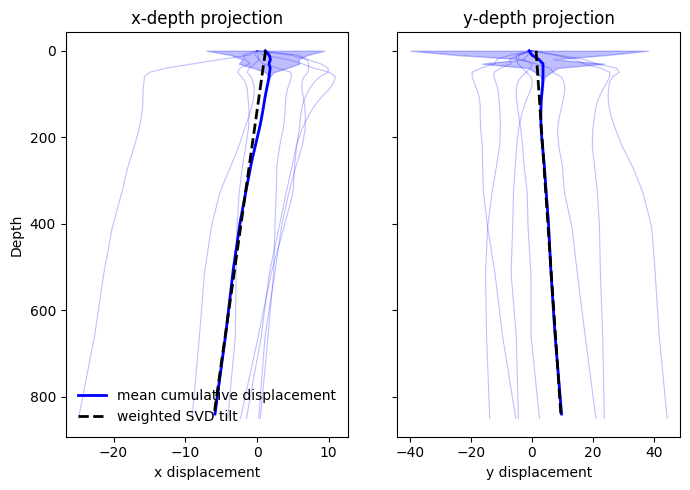

Eddy 647: tilt not measurable, too few valid points.


In [5]:
# ks = np.array([10, 50, 70, 100, 10, 130, 140, 150, 180, 200])
# ks += 7

for k in range(len(df_large_tilt)):

    data = df_large_tilt.iloc[k]
    eddy, ref_day = data.Eddy, data.day_idx
    
    plot_tilt_method(
        dic_all=dic_vert,
        eddy=eddy,
        ref_day_idx=ref_day,
        ax_x=None,
        ax_y=None,
        num=6,
        depth_int=10,
        max_depth=1000,
        min_depth_range=200,
        color='b',
        show=True
    )



In [6]:
max_spreads = []
for row in df_ameda.itertuples(index=False):
    try:
        df = dic_vert[f'Eddy{row.Eddy}'][f'Day{row.Day}']

        max_spread, _, _ = tilt_distance_Li(
            df['xc'].values,
            df['yc'].values,
            np.abs(df['Depth'].values),
            zmax=1000
        )
    except Exception:
        max_spread = np.nan
    max_spreads.append(max_spread)

df_ameda['max_spread'] = max_spreads


In [7]:
df_ameda['tdiff'] = (df_ameda.TiltDis - df_ameda.max_spread).abs()


<Axes: >

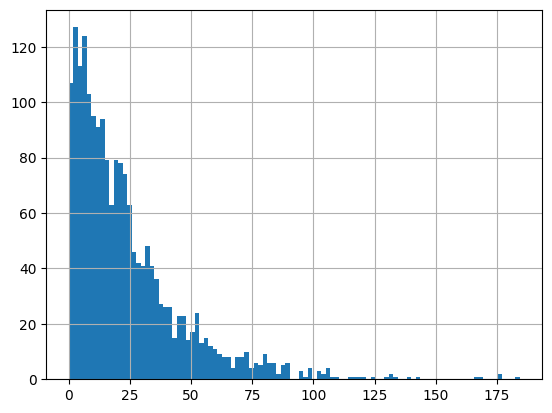

In [8]:
df_ameda['tdiff'].hist(bins=100)


In [9]:
df_large_diff = df_ameda[df_ameda.tdiff > 200]
df_large_diff


,Eddy,Day,Cyc,lon,lat,ic,jc,xc,yc,w,...,shapes2,interaction,interaction2,area,deta,TiltDis,TiltDir,day_idx,max_spread,tdiff


In [10]:
for k in range(len(df_large_diff)):

    data = df_large_diff.iloc[k]
    eddy, ref_day = data.Eddy, data.day_idx
    
    plot_tilt_method(
        dic_all=dic_vert,
        eddy=eddy,
        ref_day_idx=ref_day,
        ax_x=None,
        ax_y=None,
        num=6,
        depth_int=10,
        max_depth=1000,
        min_depth_range=200,
        color='b',
        show=True
    )
    

<Axes: >

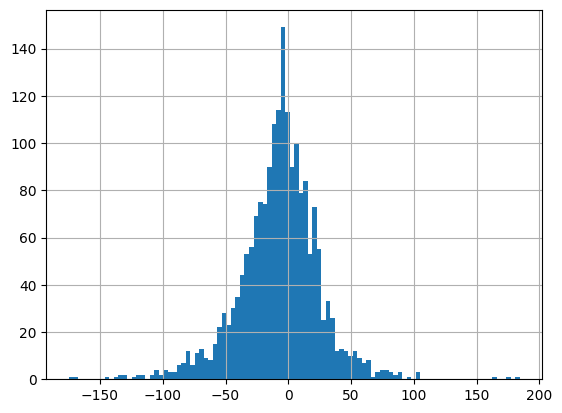

In [11]:
df_ameda['tvecdiff'] = df_ameda.TiltDis - df_ameda.max_spread
df_ameda.tvecdiff.hist(bins=100)


In [12]:
df_big_tilt_to_spread = df_ameda[df_ameda.tvecdiff > 100]
df_big_tilt_to_spread


,Eddy,Day,Cyc,lon,lat,ic,jc,xc,yc,w,...,interaction,interaction2,area,deta,TiltDis,TiltDir,day_idx,max_spread,tdiff,tvecdiff
2775,77,1647,AE,158.016129,-32.737261,229,190,740.062118,937.657596,0.000012,...,NaN,NaN,4503.063715,-0.000015,196.507627,355.491728,14,12.334471,184.173156,184.173156
2776,77,1648,AE,157.979,-32.737261,228,190,736.725265,936.456558,0.000012,...,119.0,NaN,5150.129304,-0.000071,185.132251,355.198261,15,8.750264,176.381988,176.381988
2777,77,1649,AE,157.867611,-32.77961,226,188,728.027200,928.380770,0.000015,...,119.0,NaN,2979.746637,-0.0,174.087739,355.186917,16,8.082801,166.004938,166.004938
6372,201,1961,CE,158.795853,-31.847932,236,214,783.144660,1057.038896,-0.000023,...,NaN,NaN,3651.782313,0.000127,127.968311,146.414371,23,24.885694,103.082617,103.082617
6373,201,1962,CE,158.795853,-31.890281,237,213,784.444000,1052.559520,-0.000023,...,NaN,NaN,3515.11109,0.000034,135.037089,145.116039,24,30.552926,104.484163,104.484163
6374,201,1963,CE,158.795853,-32.017328,237,210,788.336411,1039.119790,-0.000026,...,NaN,NaN,2466.582351,0.000084,150.473015,143.617477,25,45.742526,104.730489,104.730489


Eddy 77: tilt not measurable, too few valid points.
Eddy 77: tilt not measurable, too few valid points.
Eddy 77: tilt not measurable, too few valid points.


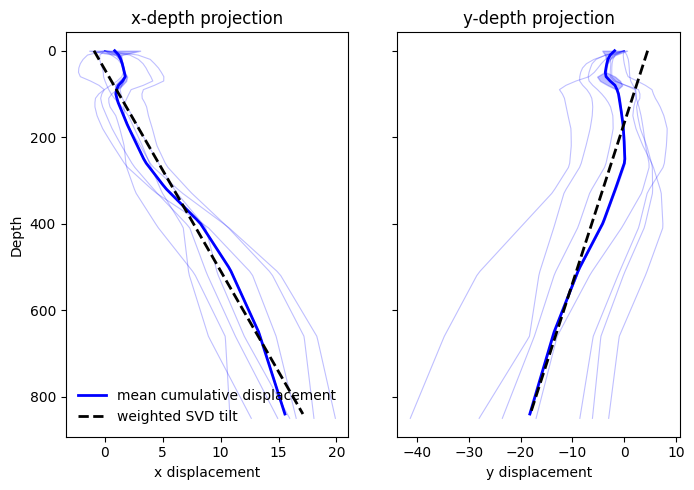

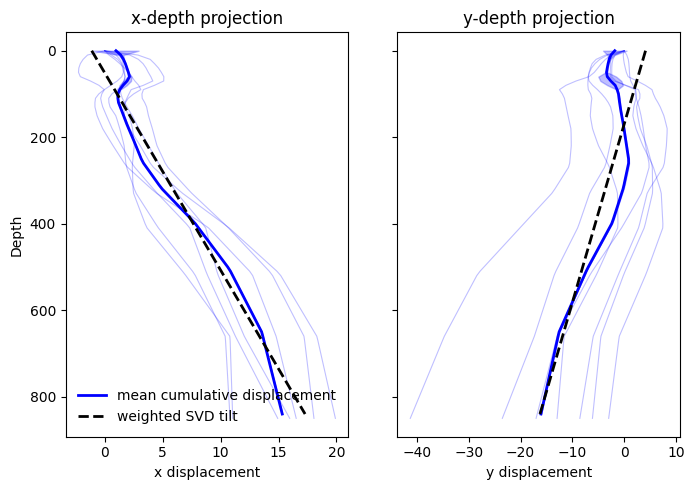

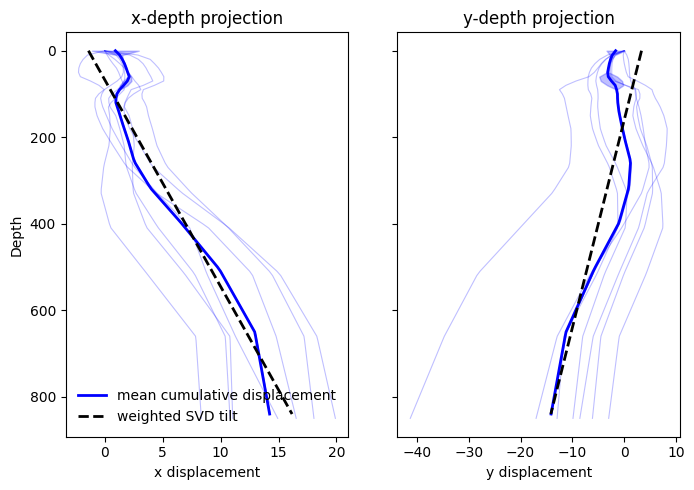

In [13]:
for k in range(len(df_big_tilt_to_spread)):

    data = df_big_tilt_to_spread.iloc[k]
    eddy, ref_day = data.Eddy, data.day_idx
    
    plot_tilt_method(
        dic_all=dic_vert,
        eddy=eddy,
        ref_day_idx=ref_day,
        ax_x=None,
        ax_y=None,
        num=6,
        depth_int=10,
        max_depth=1000,
        min_depth_range=200,
        color='b',
        show=True
    )
    

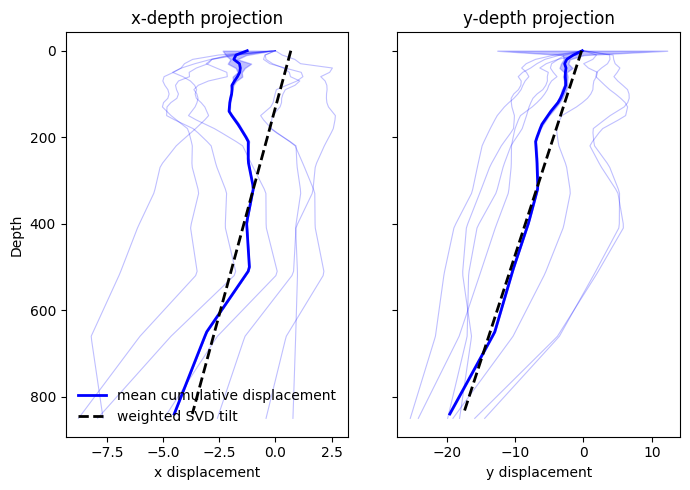

(<Figure size 700x500 with 2 Axes>,
 (<Axes: title={'center': 'x-depth projection'}, xlabel='x displacement', ylabel='Depth'>,
  <Axes: title={'center': 'y-depth projection'}, xlabel='y displacement'>),
           dxc       dyc   sum_dxc    sum_dyc   var_dxc    var_dyc  total_var  \
 0   -1.252381 -0.184139 -1.252381  -0.184139  1.093024  12.420030  13.513054   
 10  -0.500473 -1.309428 -1.752853  -1.493568  0.453849   1.545014   1.998864   
 20  -0.096562 -0.954165 -1.849416  -2.447733  0.149705   0.439876   0.589581   
 30   0.251008 -0.312292 -1.598407  -2.760025  0.518227   0.538807   1.057034   
 40   0.039097  0.204464 -1.559311  -2.555560  0.198602   0.948934   1.147536   
 ..        ...       ...       ...        ...       ...        ...        ...   
 800 -0.075924 -0.347138 -4.198639 -18.172204  0.005496   0.046453   0.051948   
 810 -0.075924 -0.347138 -4.274564 -18.519342  0.005496   0.046453   0.051948   
 820 -0.075924 -0.347138 -4.350488 -18.866480  0.005496   0.046453  

In [14]:
    plot_tilt_method(
        dic_all=dic_vert,
        eddy=627,
        ref_day_idx=50,
        ax_x=None,
        ax_y=None,
        num=6,
        depth_int=10,
        max_depth=1000,
        min_depth_range=200,
        color='b',
        show=True
    )
